- Test the snapshot interpolation in forward simulation.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

from pmwd import (
    Configuration,
    Cosmology, SimpleLCDM,
    boltzmann,
    white_noise, linear_modes,
    lpt,
    nbody,
)
from pmwd.interp_util import interptcl
from pmwd.observe import create_obsvbl

import matplotlib.pyplot as plt

In [2]:
ptcl_spacing = 4.
ptcl_grid_shape = (64,) * 3
conf = Configuration(ptcl_spacing, ptcl_grid_shape, mesh_shape=1)
# last two snapshots with one more interpolated in between
conf = conf.replace(a_snapshots=(conf.a_nbody[-2],
                                 (conf.a_nbody[-2] + conf.a_nbody[-1]) / 2,
                                 conf.a_nbody[-1]))

print(f'Simulating {conf.ptcl_num} particles with a {conf.mesh_shape} mesh for {conf.a_nbody_num} time steps.')
print(f'last two nbody a step: ... {conf.a_nbody[-2:]}')
print(f'observable snapshots a: {jnp.array(conf.a_snapshots)}')

cosmo = SimpleLCDM(conf)

cosmo = boltzmann(cosmo, conf)
seed = 0
modes = white_noise(seed, conf)
modes = linear_modes(modes, cosmo, conf)

ptcl, obsvbl = lpt(modes, cosmo, conf)
obsvbl = create_obsvbl(ptcl, conf)
ptcl, obsvbl = nbody(ptcl, obsvbl, cosmo, conf)

Simulating 262144 particles with a (64, 64, 64) mesh for 63 time steps.
last two nbody a step: ... [0.984 1.   ]
observable snapshots a: [0.984 0.992 1.   ]


In [3]:
print('check if the last snapshot in obsvbl agrees with ptcl')

print('max rel error in disp: ', jnp.abs(ptcl.disp / obsvbl['snaps'][2].disp - 1).max())
print('max rel error in vel: ', jnp.abs(ptcl.vel / obsvbl['snaps'][2].vel - 1).max())

check if the last snapshot in obsvbl agrees with ptcl
max rel error in disp:  0.0
max rel error in vel:  0.0


check the interpolated snapshot between the last two steps
compare with the interpolation in one step
rel error in disp magnitude
max:  2.3841858e-07


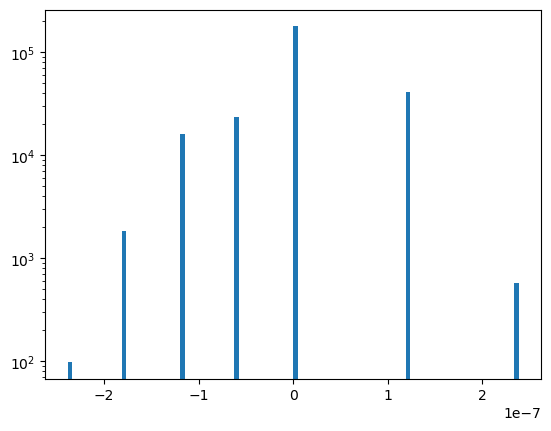

rel error in vel magnitude
max:  9.202957e-05


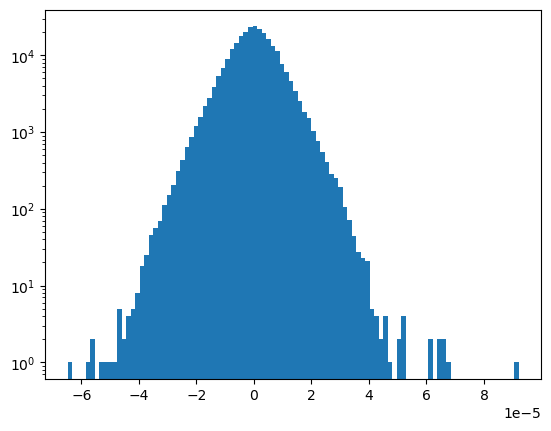

In [4]:
print('check the interpolated snapshot between the last two steps')
print('compare with the interpolation in one step')

a0, a1 = obsvbl['a_snaps'][0], obsvbl['a_snaps'][2]
a_itp = conf.a_snapshots[1]
ptcl0, ptcl1 = obsvbl['snaps'][0], obsvbl['snaps'][2]

iptcl = interptcl(ptcl0, ptcl1, a0, a1, a_itp, cosmo)

i_disp = jnp.sqrt(jnp.sum(iptcl.disp**2, axis=1))
i_vel = jnp.sqrt(jnp.sum(iptcl.vel**2, axis=1))
o_disp = jnp.sqrt(jnp.sum(obsvbl['snaps'][1].disp**2, axis=1))
o_vel = jnp.sqrt(jnp.sum(obsvbl['snaps'][1].vel**2, axis=1))

print('rel error in disp magnitude')
print('max: ', jnp.abs(i_disp / o_disp - 1).max())
plt.hist(i_disp / o_disp - 1, bins=100, log=True); plt.show()

print('rel error in vel magnitude')
print('max: ', jnp.abs(i_vel / o_vel - 1).max())
plt.hist(i_vel / o_vel - 1, bins=100, log=True); plt.show()